In [12]:
import numpy as np
import pandas as pd
import pm4py

from pm4py.algo.filtering.log.variants import variants_filter
from pm4py.statistics.traces.generic.log import case_statistics

In [13]:
# pandas dataframe setup on event log for processing by pm4py
df = pd.read_csv('EDHospital.csv')

# creating event log from df
log = pm4py.format_dataframe(df, 
                             case_id='Case ID',
                             activity_key='Activity',
                             timestamp_key='Complete Timestamp'
                            )

# getting durations of average durations for activities for each variant
variants_paths_duration = pm4py.get_variants_paths_duration(log)

# helper function getting average total flow time for each variant
def get_total_flow_time_variants(ascending: bool):
    
    variant_paths_flow_time = variants_paths_duration[['@@flow_time', '@@variant_column']]

    total_variant_paths_flow_time = variant_paths_flow_time.groupby('@@variant_column').sum()

    return total_variant_paths_flow_time.sort_values(by=['@@flow_time'], ascending=ascending)

What is the most common sequence of activities from start to end (aka variant)?

In [14]:
# extract all variants from the event log in descending order
variants = pm4py.get_variants(log)

print("Most Common Variant: ", list(variants.keys())[0],
      "\nOccurences", variants[list(variants.keys())[0]])

Most Common Variant:  ('Reception', 'Nurse admission', 'Order blood tests', 'Last lab tests results', 'Doctor admission', 'Discharge (Doctor)', 'Discharge') 
Occurences 7994


What is the most common activity?

In [15]:
# activities and their occurences
df['Activity'].value_counts(dropna=False)

Activity
Reception                 55079
Discharge                 55079
Doctor admission          54871
Nurse admission           54300
Discharge (Doctor)        54213
Last lab tests results    41268
Order Imaging test        29730
Order blood tests         28043
Imaging                   27824
Additional vitals         25188
Order Consultant          15192
Consultant                12954
Imaging decrypting         7110
Order external exams        506
External exams              482
Name: count, dtype: int64

What are the average durations of activities, sorted from shortest to longest?

In [16]:
# function for calculating the average time to complete an activity across all variants
def average_flow_time(activity: str):
    
    # filtering durations by activity and calculating their mean
    return variants_paths_duration[variants_paths_duration['concept:name'] == activity]['@@flow_time'].mean()

# getting array of activity names
activites = df['Activity'].unique()

# printing activities and their respective avg flow time
for activity in activites:
    print(activity, "\n" , "Average Flow Time: ", average_flow_time(activity), "\n")

Reception 
 Average Flow Time:  1965.8355652204884 

Nurse admission 
 Average Flow Time:  797.7446639683794 

Additional vitals 
 Average Flow Time:  3968.830326423553 

Last lab tests results 
 Average Flow Time:  2971.525294618539 

Doctor admission 
 Average Flow Time:  1047.5144633005245 

Discharge (Doctor) 
 Average Flow Time:  4701.739932613474 

Discharge 
 Average Flow Time:  nan 

Order blood tests 
 Average Flow Time:  1456.7610964703638 

Order Imaging test 
 Average Flow Time:  2067.3531167012634 

Imaging 
 Average Flow Time:  4961.356766458055 

Order Consultant 
 Average Flow Time:  3126.3158529984858 

Consultant 
 Average Flow Time:  5797.122374516051 

Imaging decrypting 
 Average Flow Time:  5714.283982401443 

Order external exams 
 Average Flow Time:  10575.059012875536 

External exams 
 Average Flow Time:  6578.7191011235955 



What are the average delays for activites?

In [17]:
# function for calculating the average delay of an activity
def average_delay(activity: str):

    # get all durations for an activity across variants
    activity_durations = variants_paths_duration[variants_paths_duration['concept:name'] == activity]['@@flow_time']
    
    # using avg duration as a baseline for the standard time to complete an activity
    avg_duration = average_flow_time(activity)
    
    # getting the difference of the assumed standard time to complete and the actual time
    activity_duration_differences = activity_durations.apply(lambda duration: duration - avg_duration)
    
    # filtering for occurences which take longer than the standard time
    activity_delays = activity_duration_differences[activity_duration_differences > 0]
    
    # averaging them and returning
    return activity_delays.mean()

# getting array of activity names
activites = df['Activity'].unique()

# printing activities and their respective avg flow time
for activity in activites:
    print(activity, "\n" , "Average Flow Time: ", average_delay(activity), "\n")

Reception 
 Average Flow Time:  1496.9740284174893 

Nurse admission 
 Average Flow Time:  3075.172338214731 

Additional vitals 
 Average Flow Time:  10150.987659931898 

Last lab tests results 
 Average Flow Time:  4910.960247336295 

Doctor admission 
 Average Flow Time:  3984.337855082663 

Discharge (Doctor) 
 Average Flow Time:  8510.9208130487 

Discharge 
 Average Flow Time:  nan 

Order blood tests 
 Average Flow Time:  1192.7653690108862 

Order Imaging test 
 Average Flow Time:  3938.950506376706 

Imaging 
 Average Flow Time:  8196.98547391032 

Order Consultant 
 Average Flow Time:  5273.5450483722325 

Consultant 
 Average Flow Time:  15756.639591215357 

Imaging decrypting 
 Average Flow Time:  12764.488438929433 

Order external exams 
 Average Flow Time:  16784.710490670568 

External exams 
 Average Flow Time:  26068.357821953334 



What is the average duration across variants and their average delay?

In [18]:
def calculate_average_time_and_delay_for_variants():
    
    variant_durations = get_total_flow_time_variants(False)['@@flow_time']
    
    avg_duration = variant_durations.mean()
    
    variant_duration_differences = variant_durations.apply(lambda duration: duration - avg_duration)
    
    variant_delays = variant_duration_differences[variant_duration_differences > 0]
    
    return variant_durations.mean(), variant_delays.mean()

avg_variant_duration, avg_variant_delays = calculate_average_time_and_delay_for_variants()

print("Average Variant Duration: ", avg_variant_duration,
      "\nAverage Variant Delay: ", avg_variant_delays)

Average Variant Duration:  37900.886769072655 
Average Variant Delay:  39396.55976311833


What is the longest path?

In [19]:
def get_longest_variant(type):
    
    total_flow_time_variants = get_total_flow_time_variants(False).reset_index()
    total_flow_time_variants['num activities'] = total_flow_time_variants['@@variant_column'].apply(lambda x: len(x))

    if type == "activity":
        
        ordered_by_activity = total_flow_time_variants.sort_values(by=['num activities'], ascending=False).reset_index()

        return ordered_by_activity.iloc[0]
    
    elif type == "time":
        
        ordered_by_time = total_flow_time_variants.sort_values(by=['@@flow_time'], ascending=False).reset_index()

        return ordered_by_time.iloc[0]
    
print("Longest variant by time: ", get_longest_variant("time"),
      "Longest variant by activities: ", get_longest_variant("activity"))

Longest variant by time:  index                                                               0
@@variant_column    (Reception, Last lab tests results, Order Cons...
@@flow_time                                                 4826340.0
num activities                                                     30
Name: 0, dtype: object Longest variant by activities:  index                                                             575
@@variant_column    (Reception, Nurse admission, Order blood tests...
@@flow_time                                                   89400.0
num activities                                                     35
Name: 0, dtype: object


Are the infrequent variants the longer or shorter cases?

In [20]:
def get_variant_frequency_df(infrequency):
    total_flow_time_variants = get_total_flow_time_variants(False).reset_index()
    total_flow_time_variants['num activities'] = total_flow_time_variants['@@variant_column'].apply(lambda x: len(x))
    variants_df = variants_paths_duration[['@@variant_column', '@@variant_count']].drop_duplicates()

    infrequent_variants = variants_df[variants_df['@@variant_count'] == infrequency]
    infrequent_variants = infrequent_variants['@@variant_column'].to_numpy()
    infrequent_variants_df = total_flow_time_variants[total_flow_time_variants[['@@variant_column']].isin(infrequent_variants).any(axis=1)]

    frequent_variants = variants_df[variants_df['@@variant_count'] > infrequency]
    frequent_variants = frequent_variants['@@variant_column'].to_numpy()
    frequent_variants_df = total_flow_time_variants[total_flow_time_variants[['@@variant_column']].isin(frequent_variants).any(axis=1)]

    return {
        "Infrequent" : {
            "avg_total_flow_time": infrequent_variants_df['@@flow_time'].mean(),
            "avg_num_activties": infrequent_variants_df['num activities'].mean()
        },
        "Frequent" : {
            "avg_total_flow_time": frequent_variants_df['@@flow_time'].mean(),
            "avg_num_activties": frequent_variants_df['num activities'].mean()
        }
    }

def print_dict(frequency_dict):
    for key, value in frequency_dict.items():
        if isinstance(value, dict):
            print_dict(value)
        else:
            print("{0} : {1}\n".format(key, value))
 
get_variant_frequency_df(1)

{'Infrequent': {'avg_total_flow_time': np.float64(40455.8743346748),
  'avg_num_activties': np.float64(13.410359600155784)},
 'Frequent': {'avg_total_flow_time': np.float64(27169.660368945457),
  'avg_num_activties': np.float64(10.537077426390404)}}

What do the Alpha +, heuristic miner, and inductive miner BPMN graphs look like? Do they differ from our BPMN model?


=== PART 4: PROCESS DISCOVERY ALGORITHMS ===
Applying three process discovery algorithms...

--- ALPHA MINER ---


C:\Users\erict\AppData\Local\Temp\ipykernel_22516\1718852963.py:13: DeprecatedWarning: discover_petri_net_alpha_plus is deprecated as of 2.3.0 and will be removed in 3.0.0. This method will be removed in a future release.
  net_alpha_plus, initial_marking_alpha, final_marking_alpha = pm4py.discover_petri_net_alpha_plus(log)


✓ Alpha+ Miner completed successfully


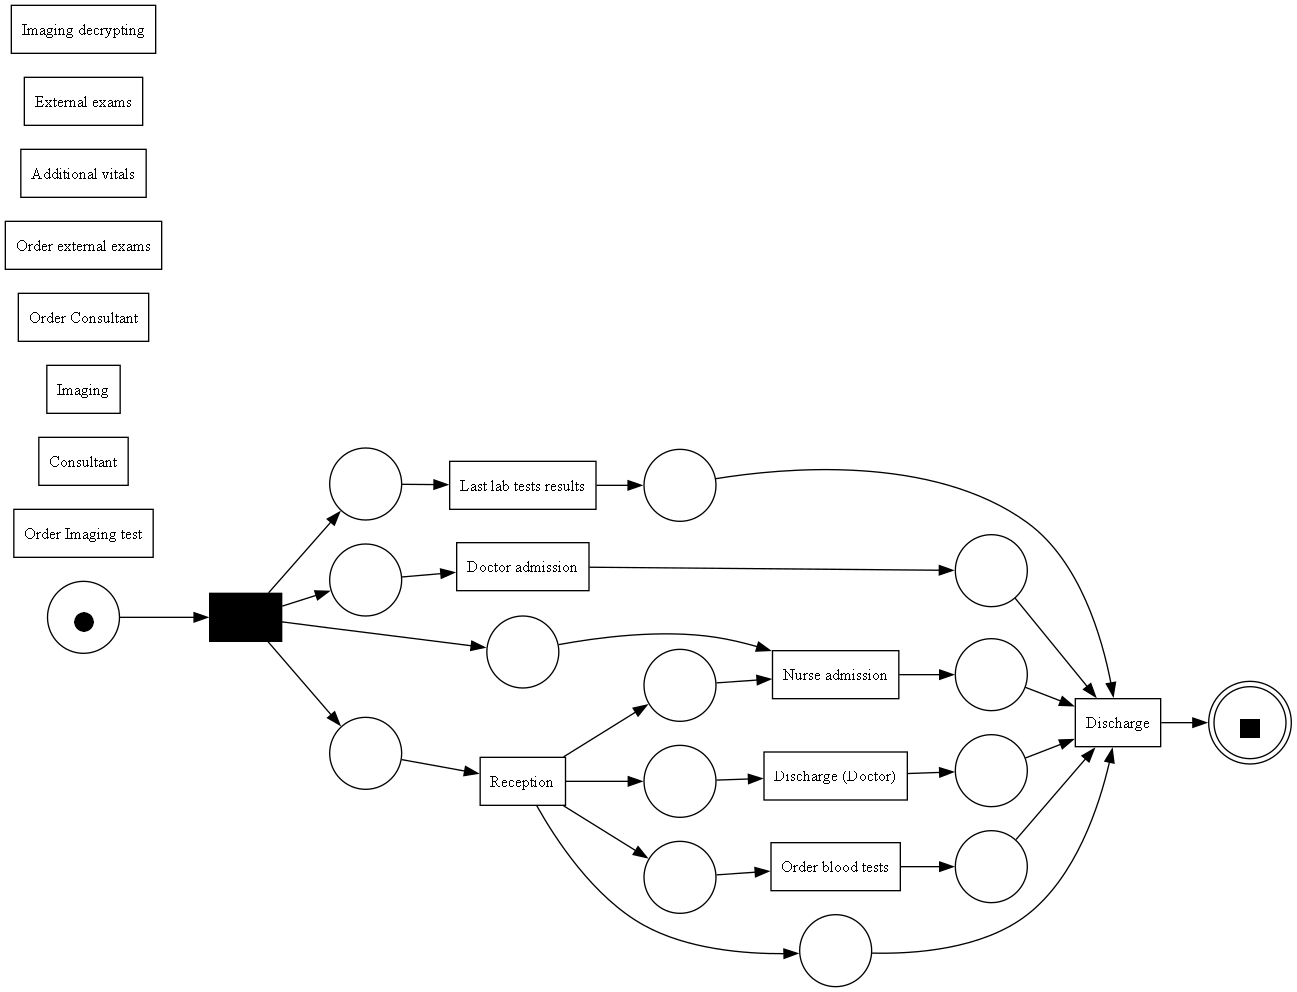

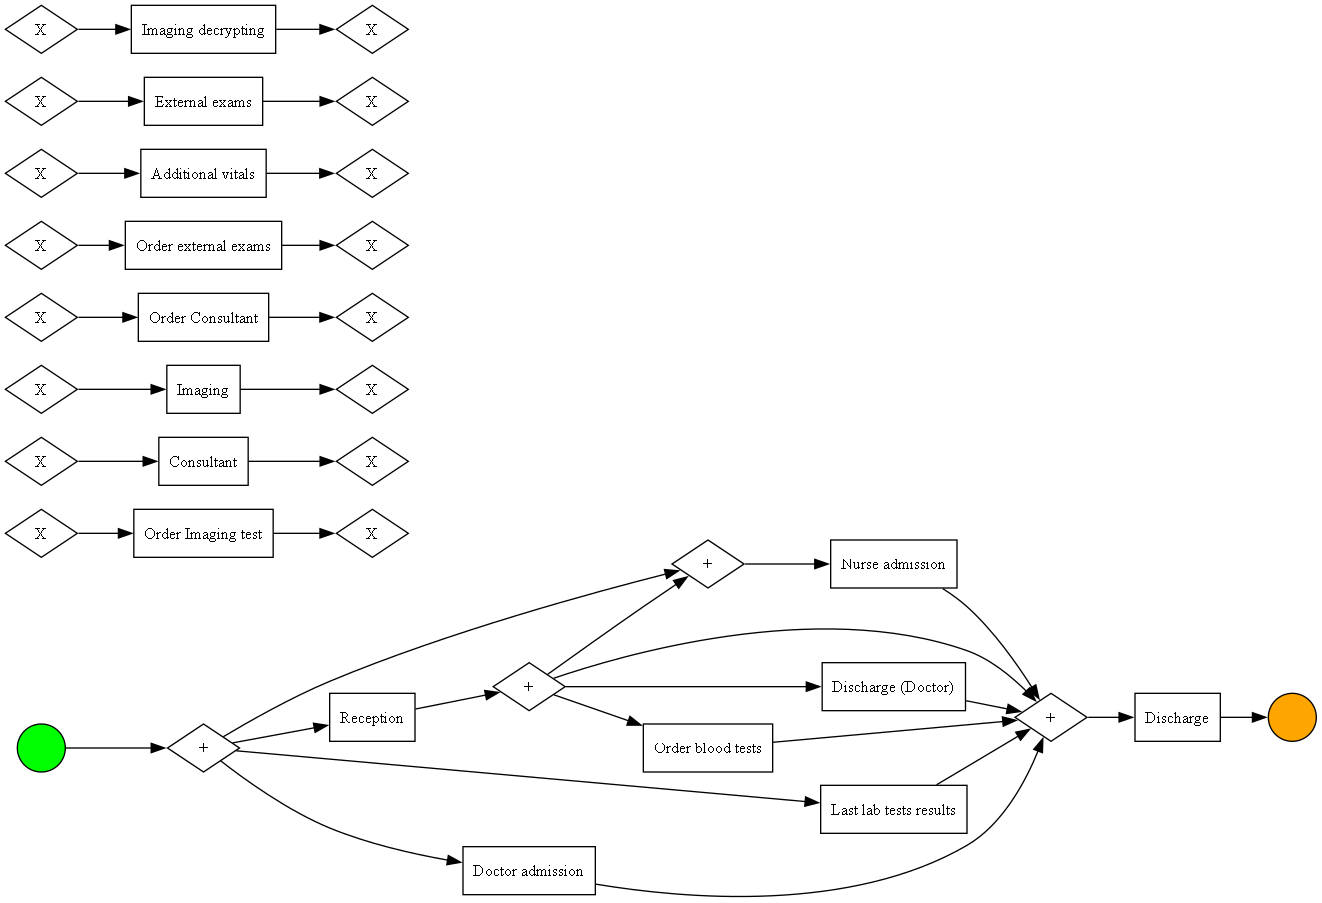

✓ Alpha Miner BPMN visualization opened

--- HEURISTIC MINER ---
✓ Heuristic Miner completed successfully


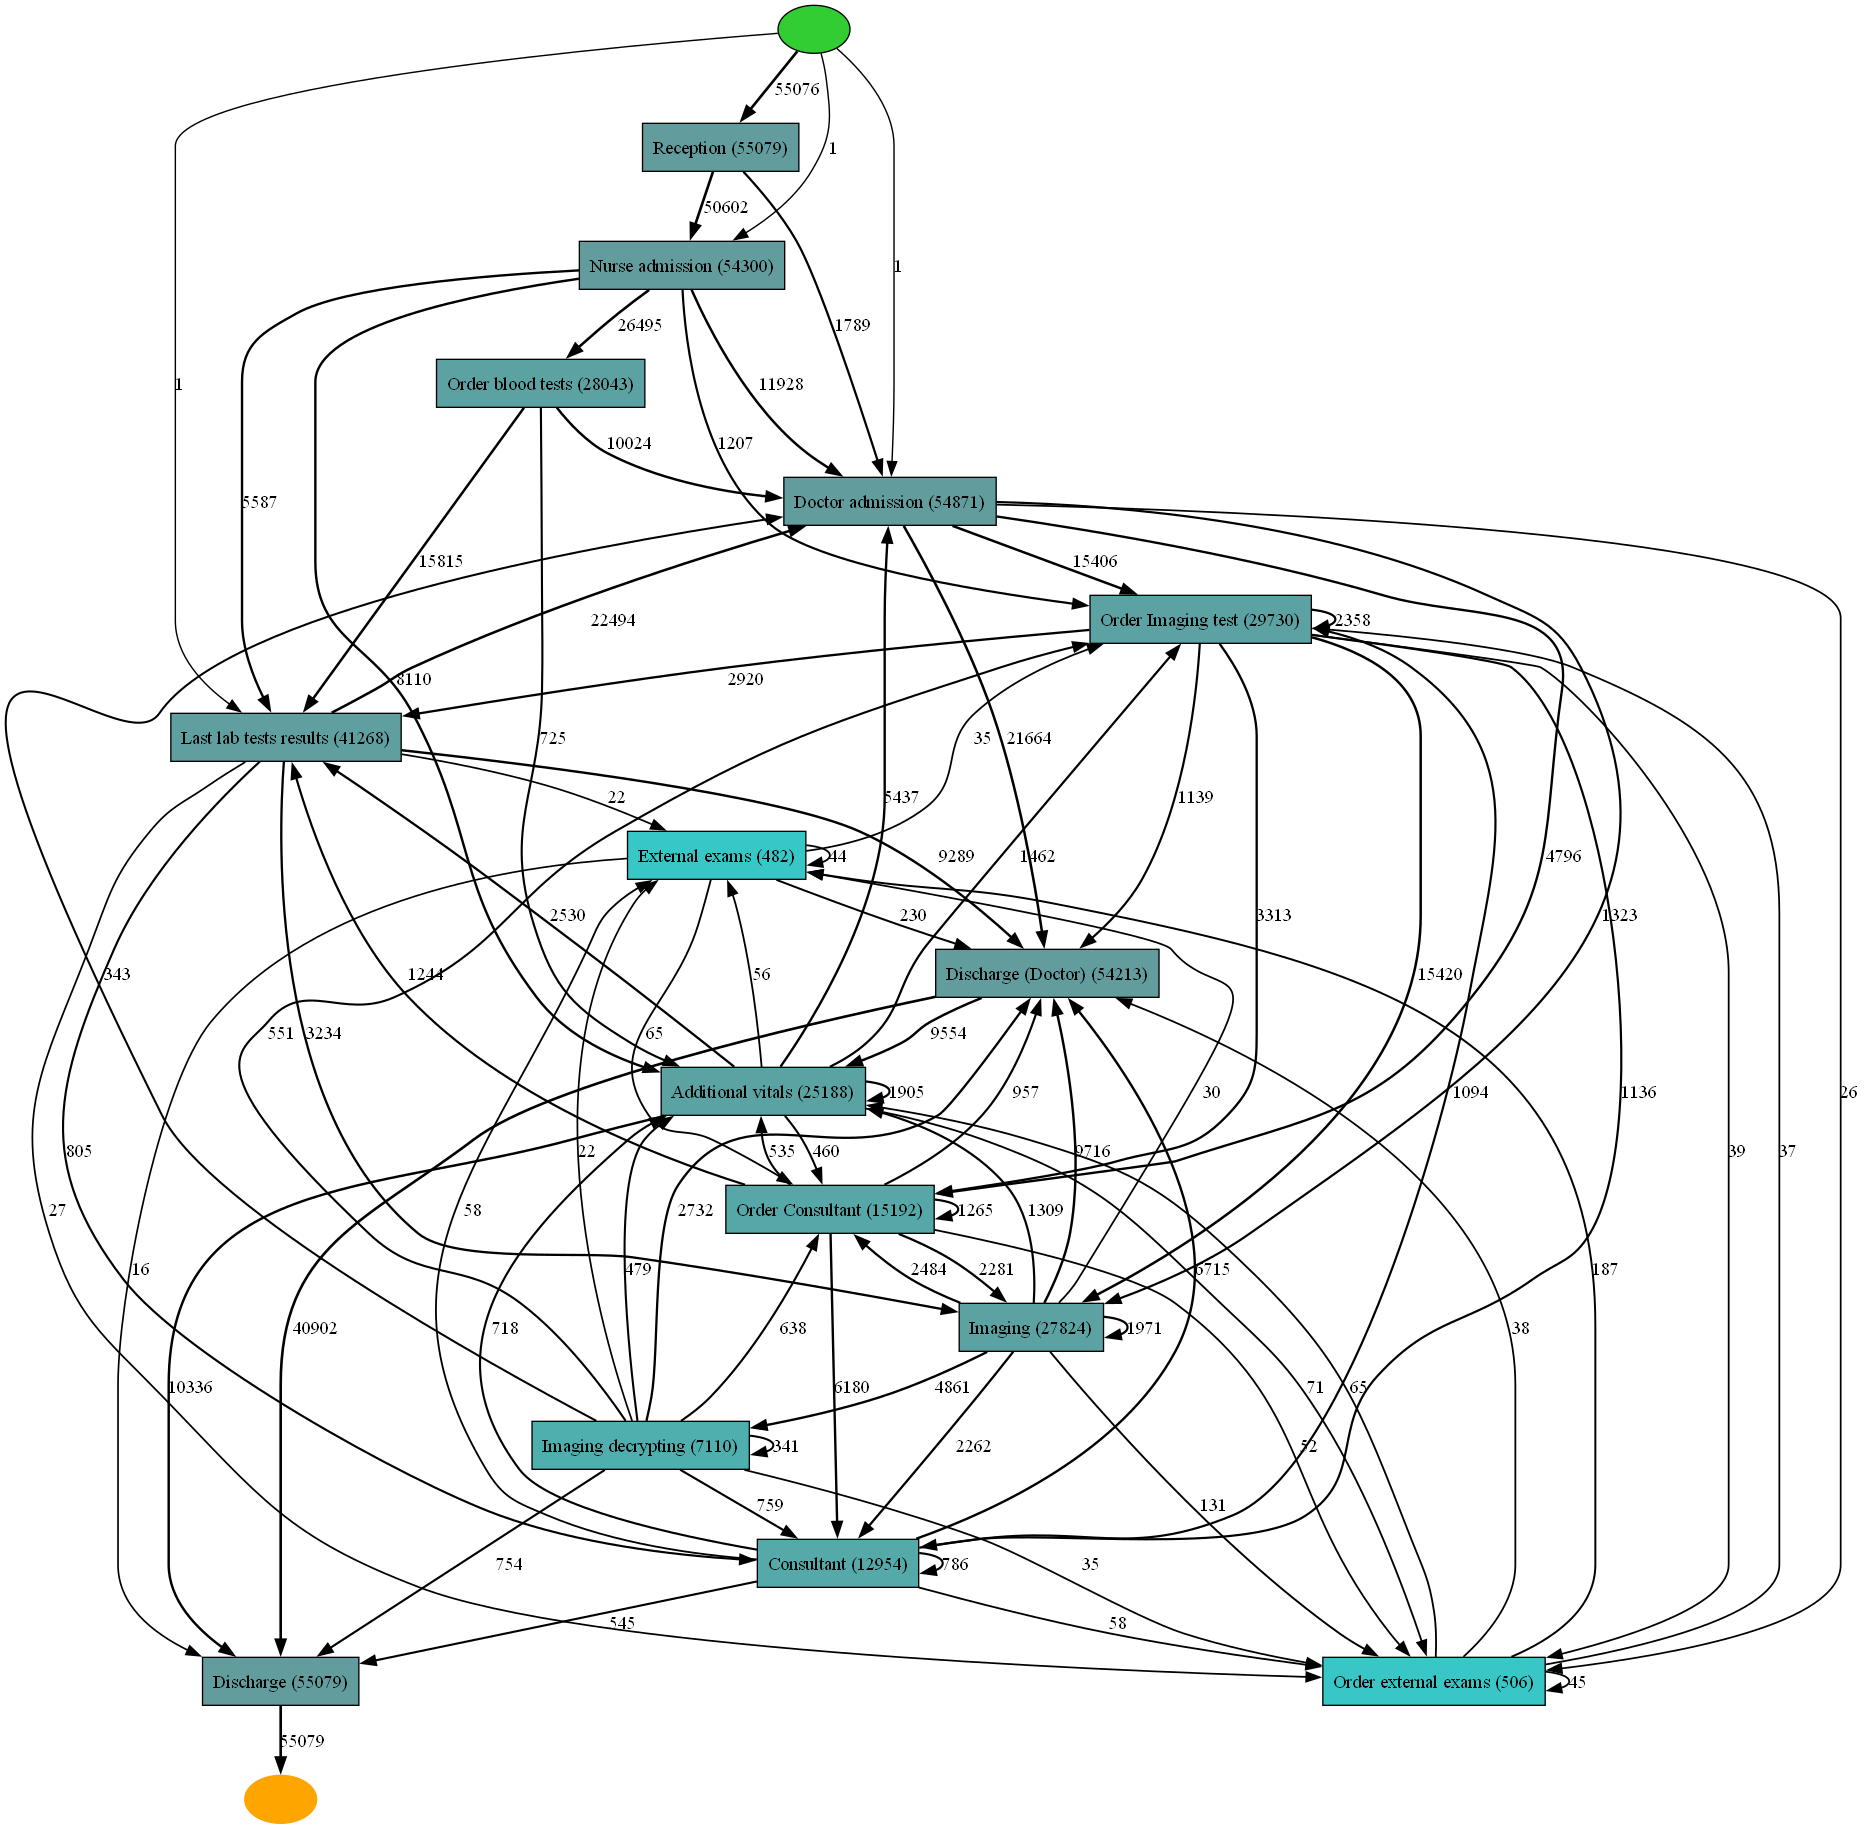

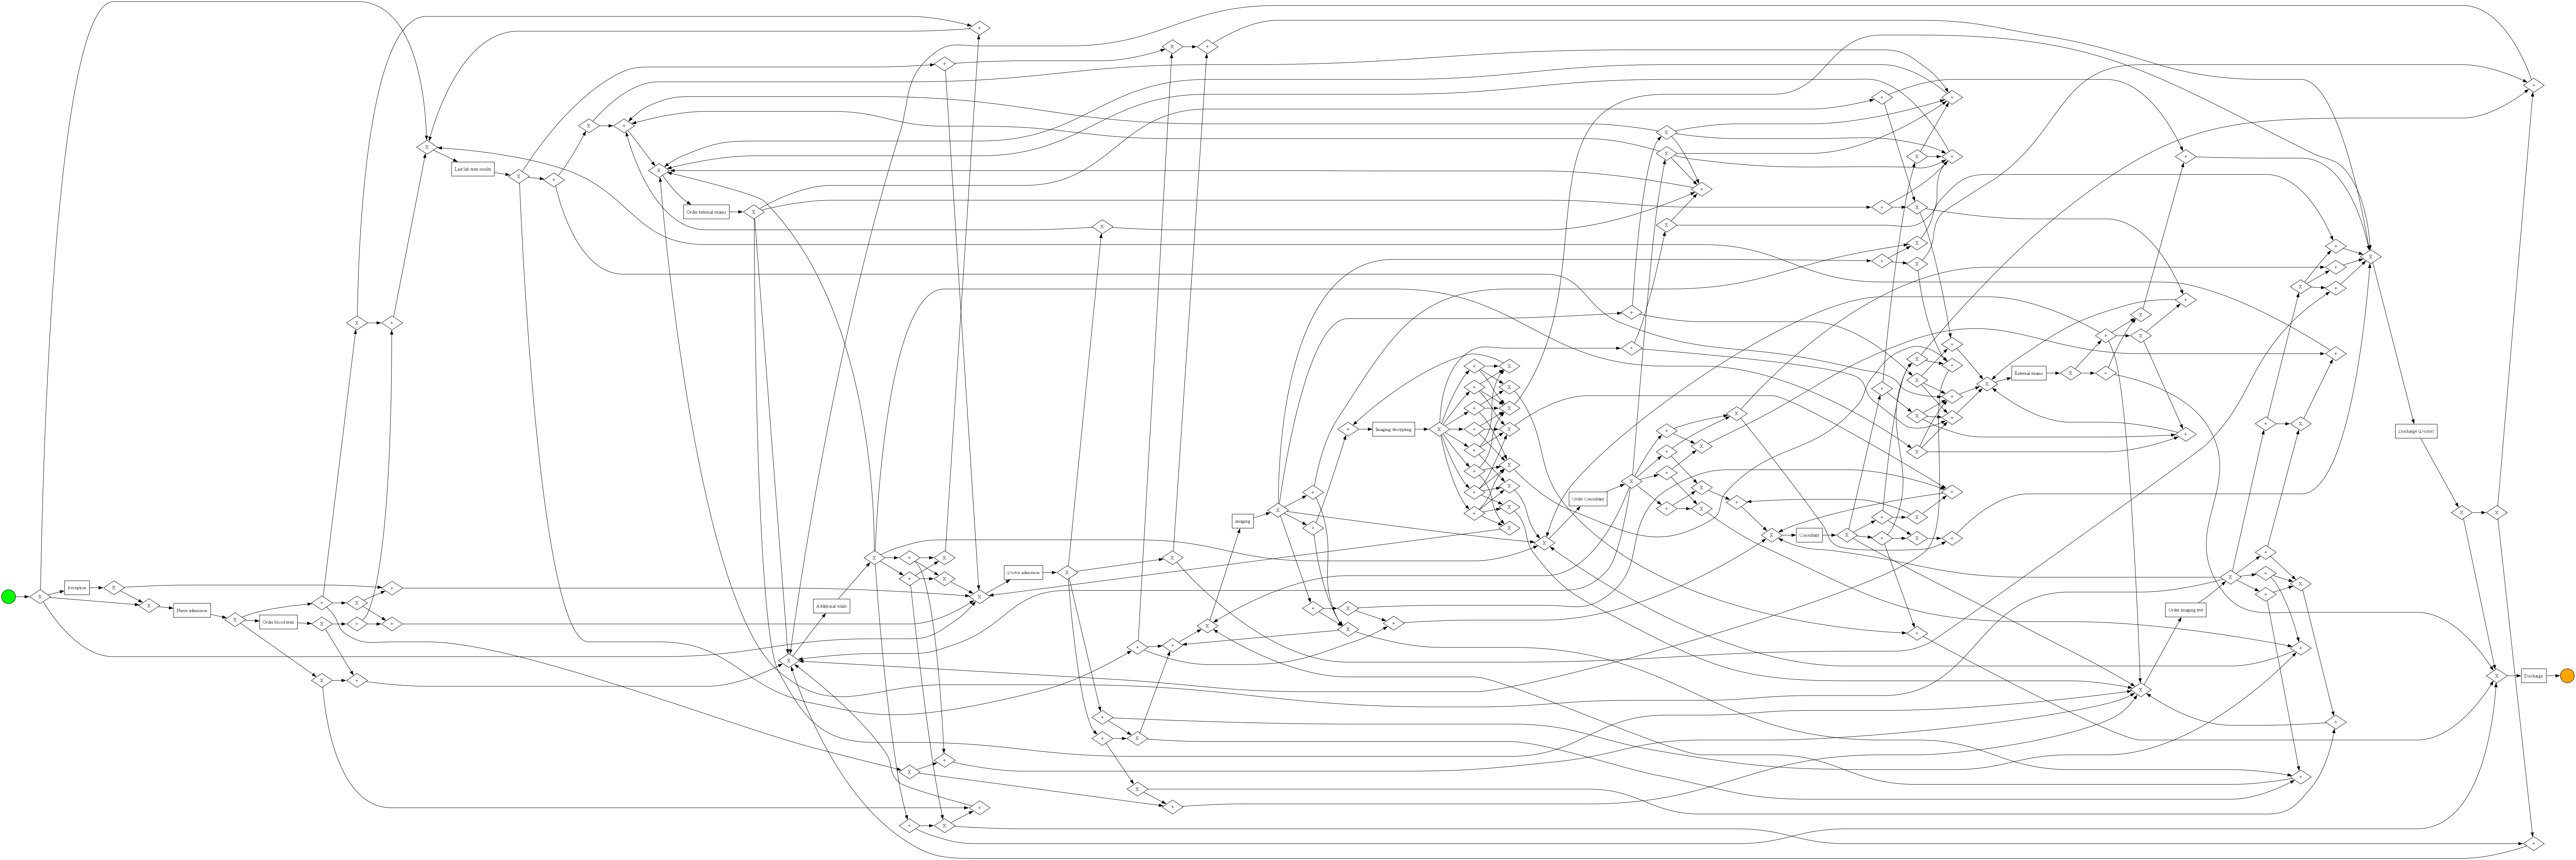

✓ Heuristic Miner BPMN visualization opened

--- INDUCTIVE MINER ---
✓ Inductive Miner process tree discovered


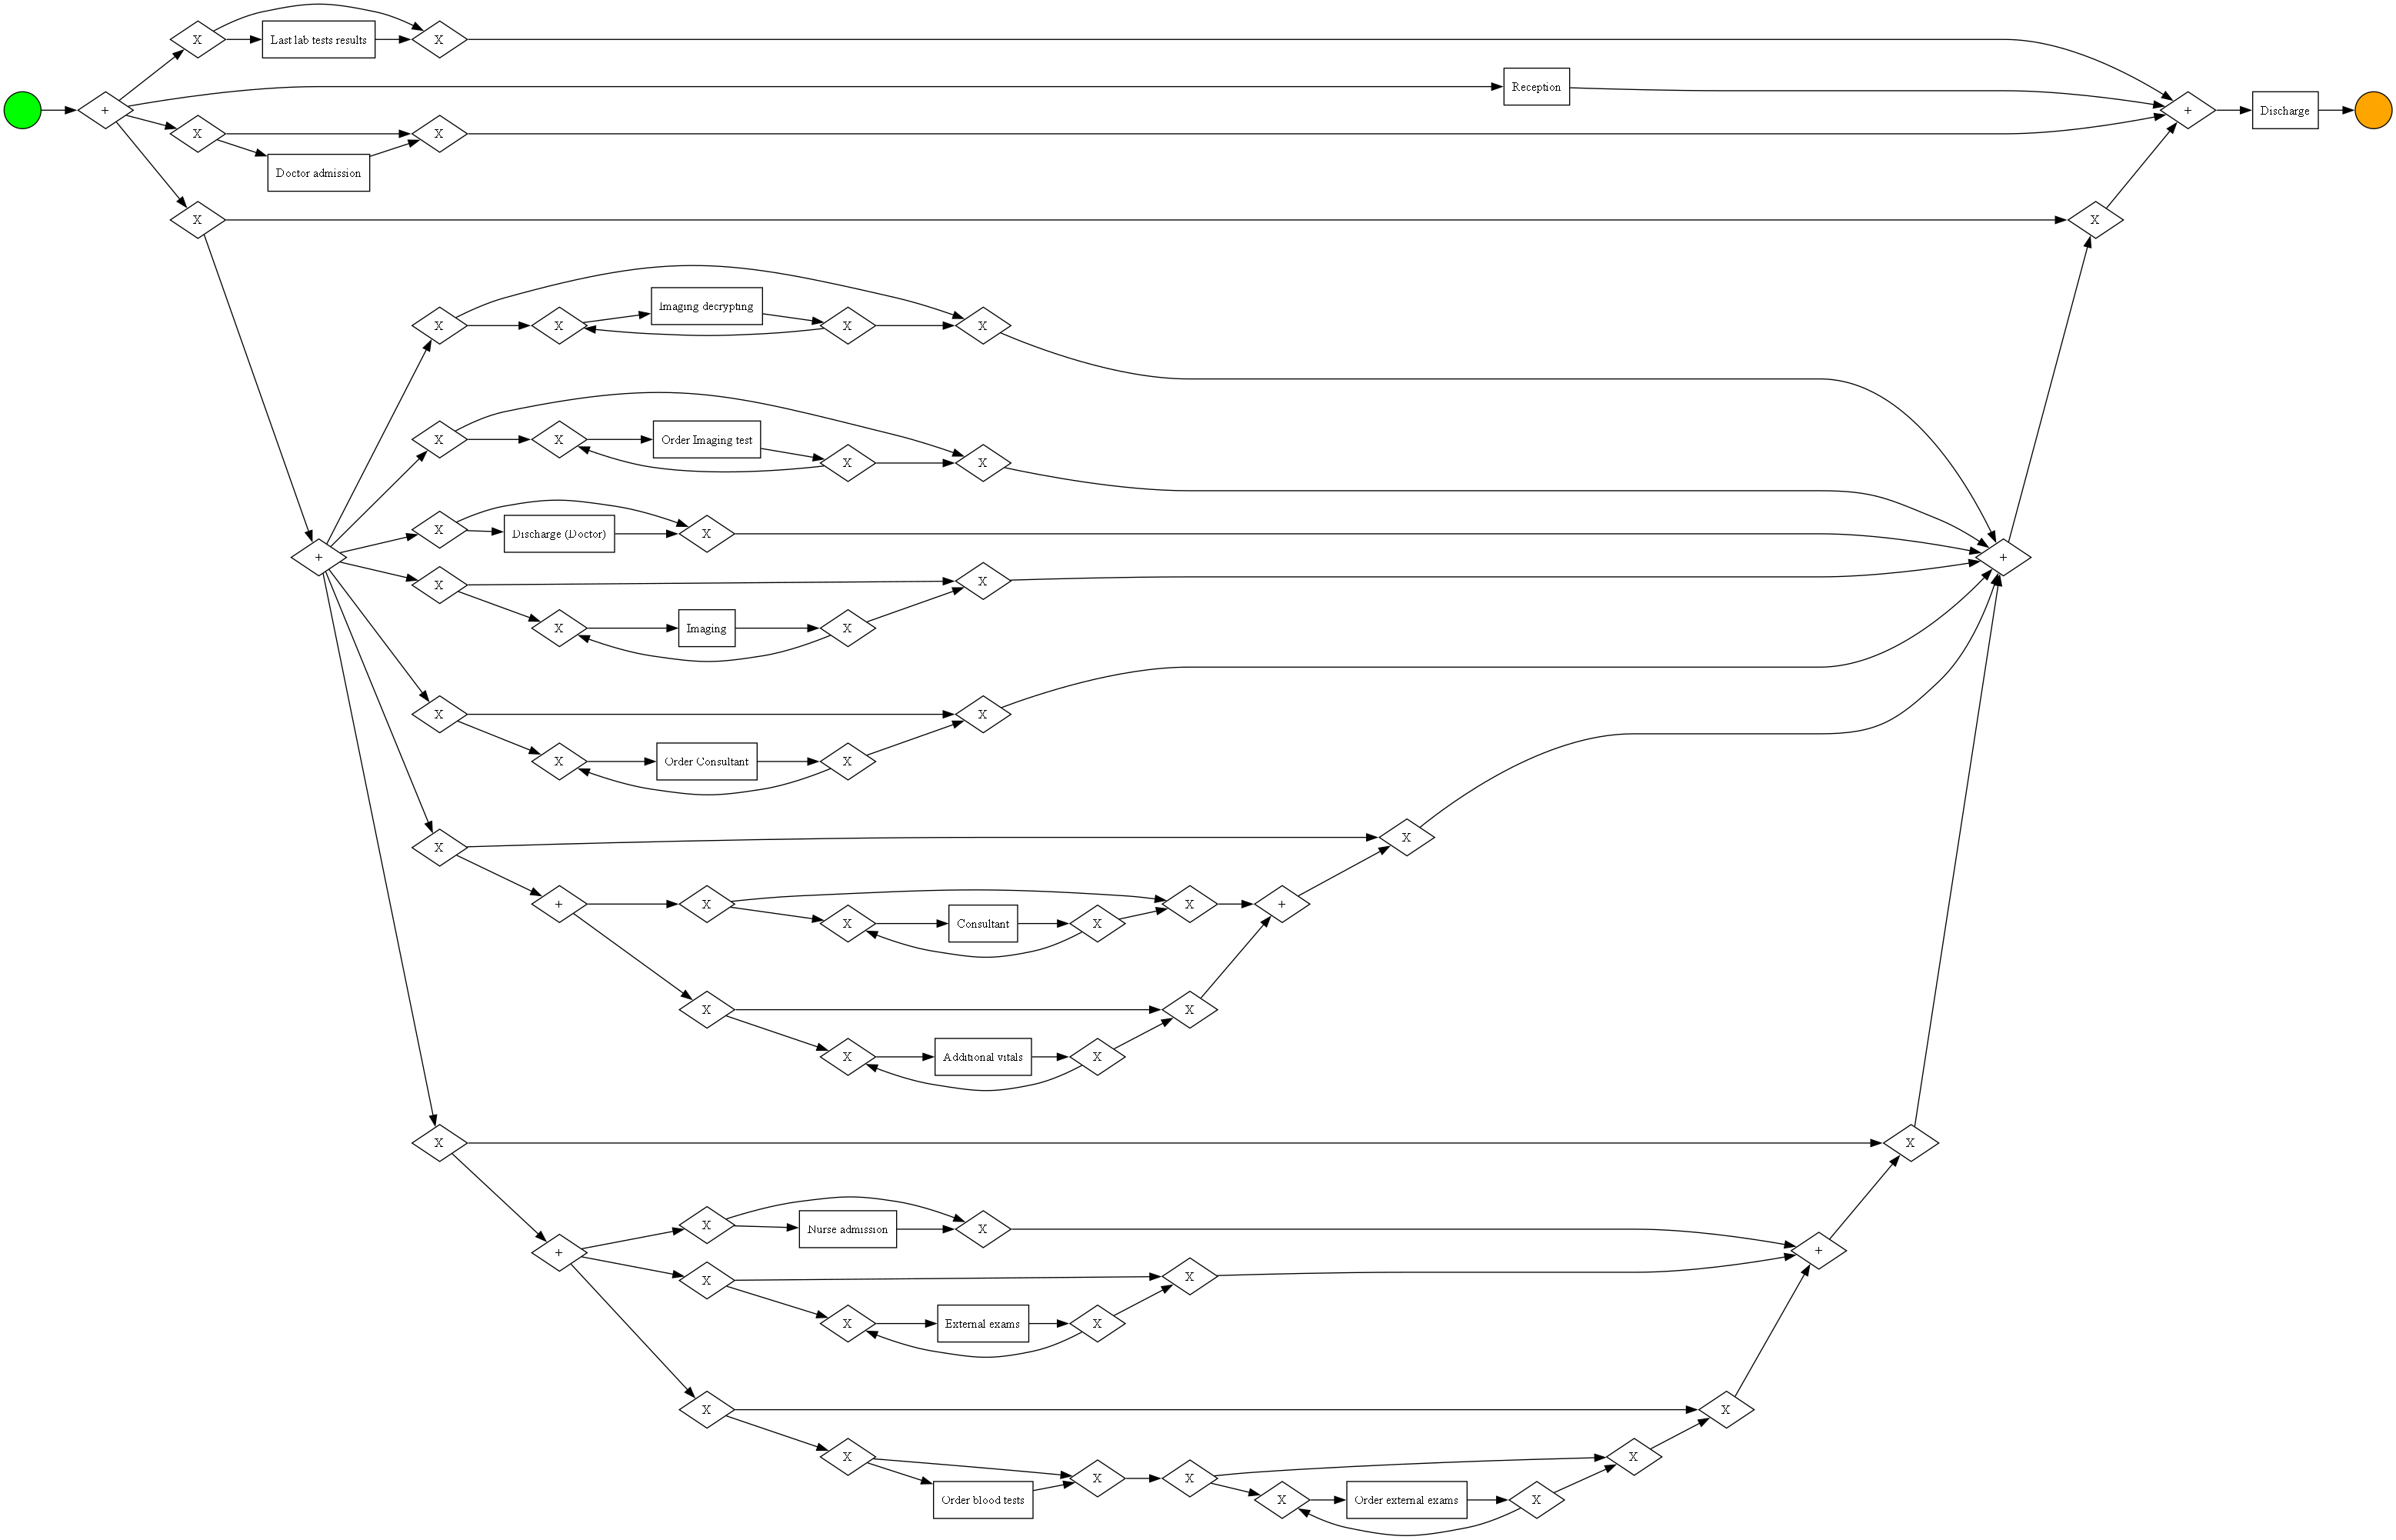

✓ Inductive Miner BPMN visualization opened


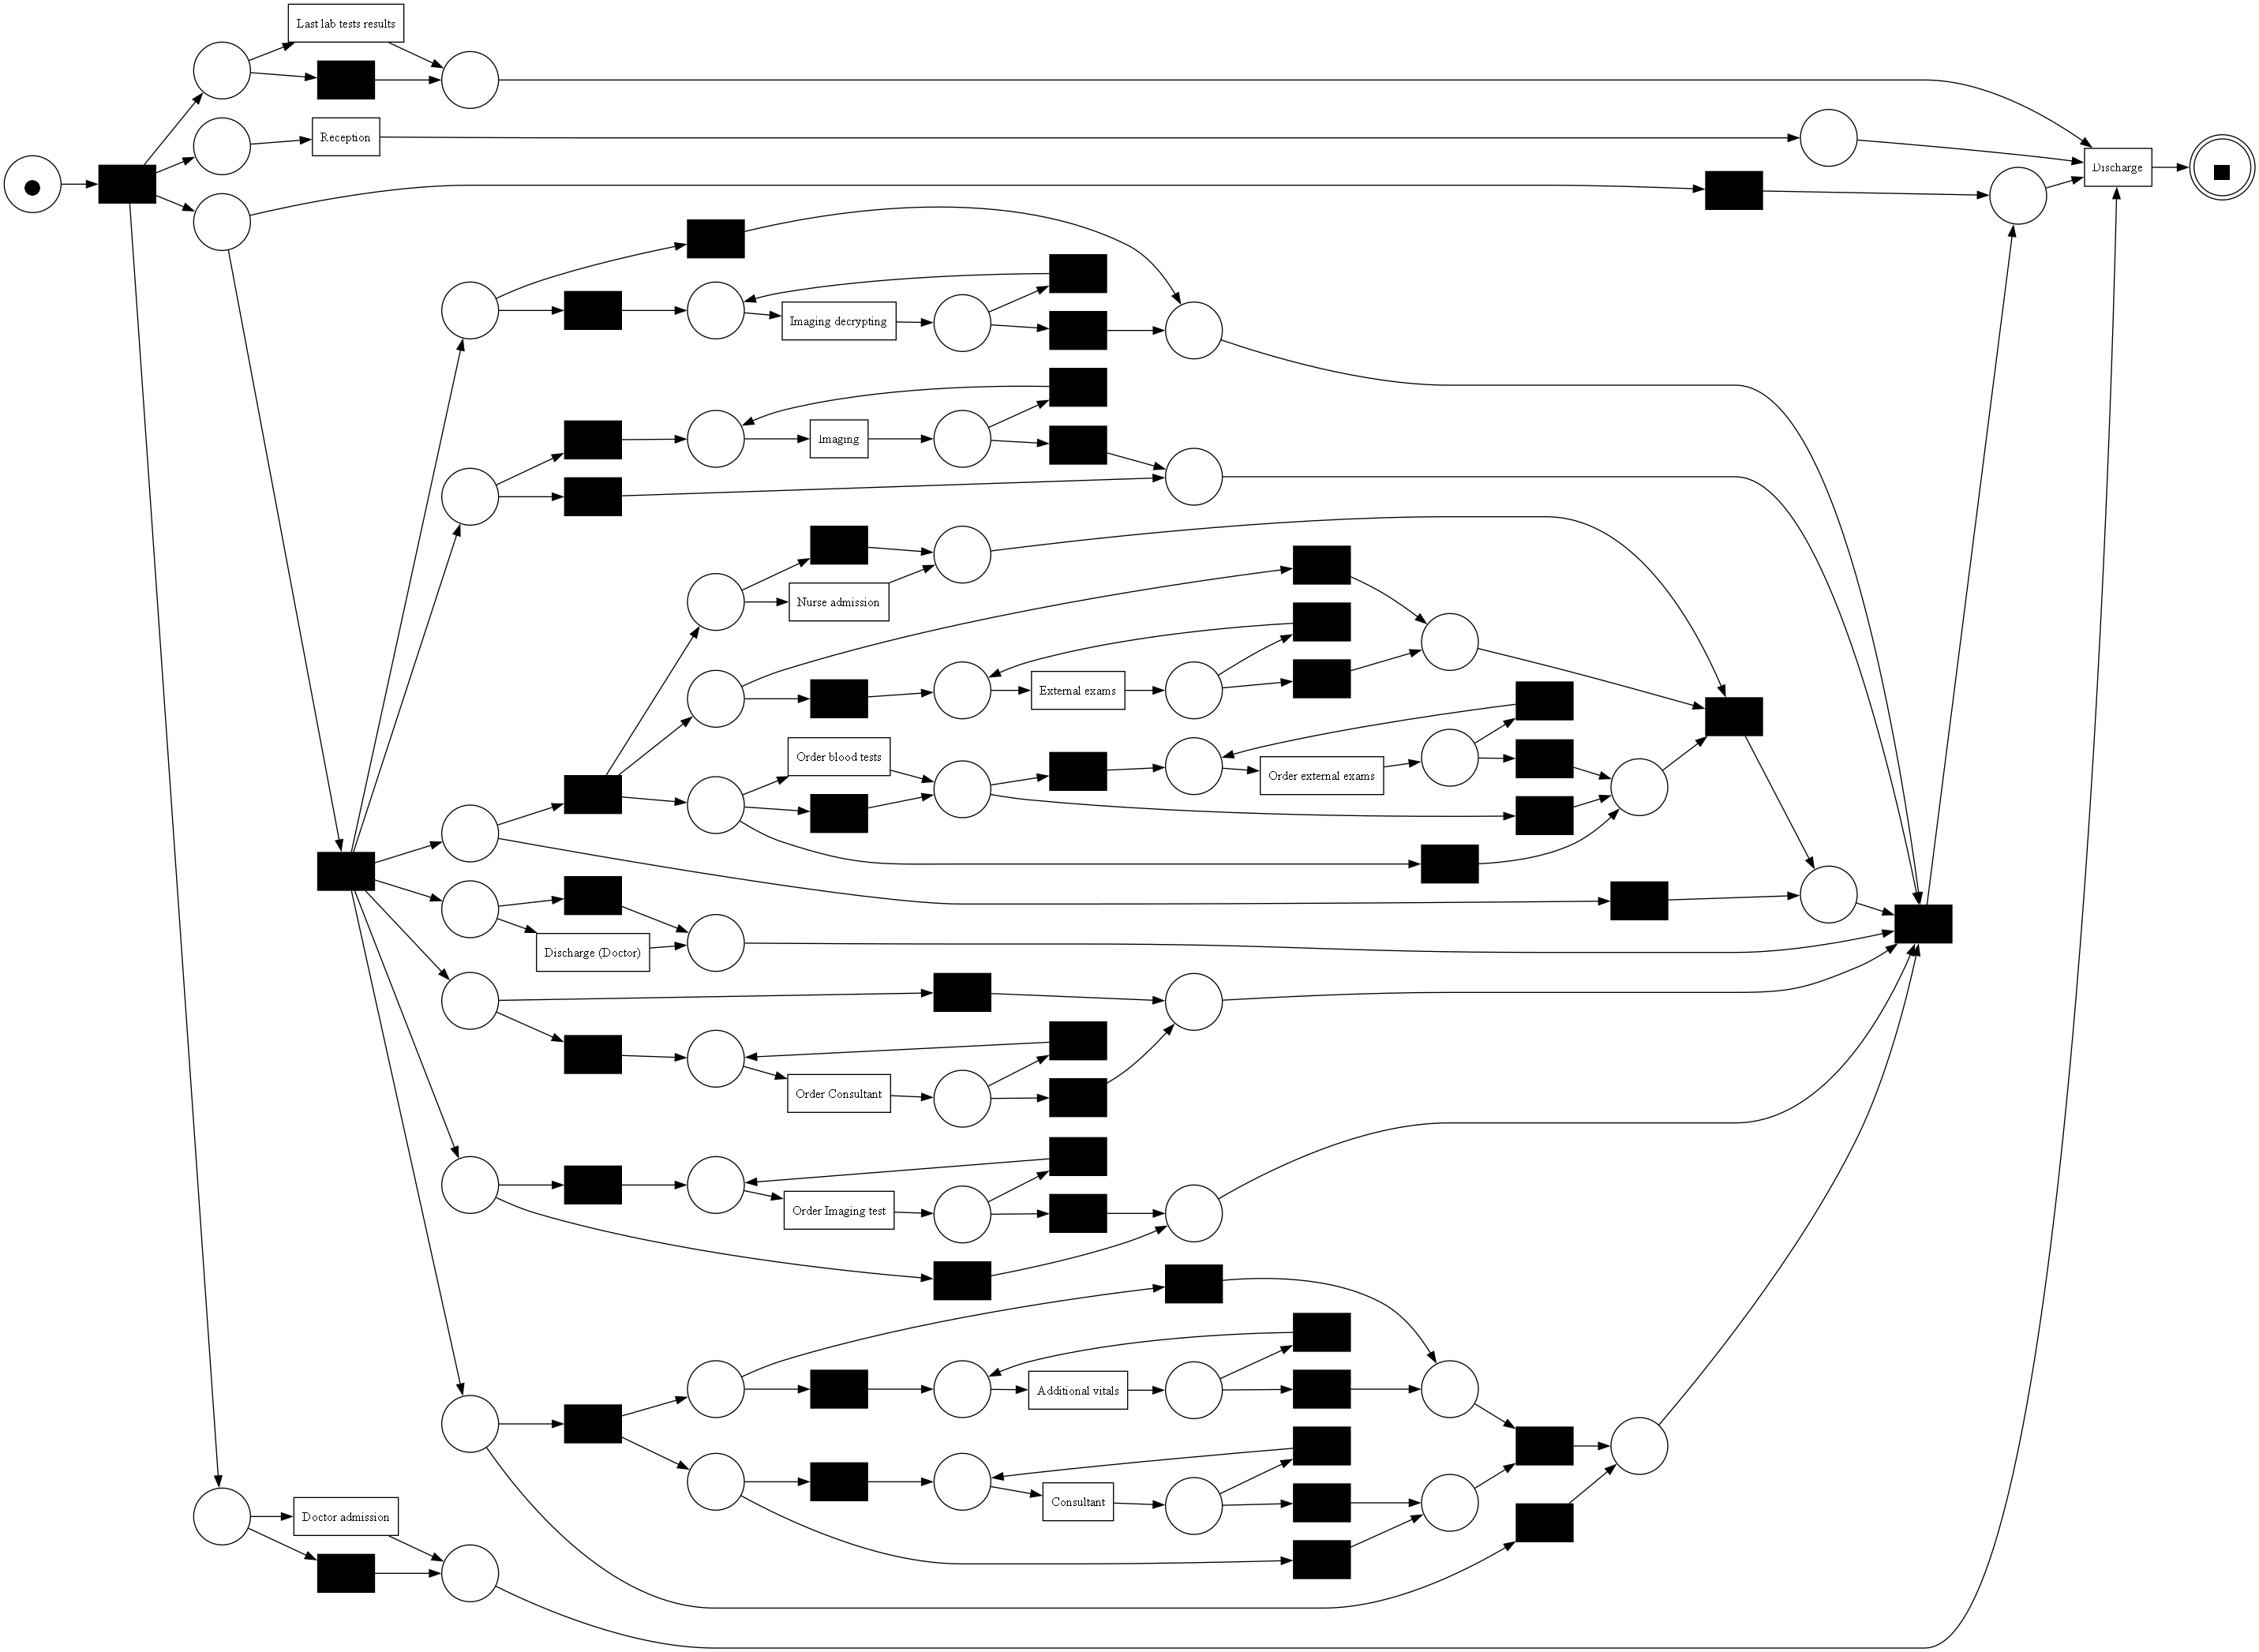

In [21]:
print("\n=== PART 4: PROCESS DISCOVERY ALGORITHMS ===")

# Convert to PM4Py EventLog object first
from pm4py.objects.conversion.log import converter as log_converter
log = log_converter.apply(log)

print("Applying three process discovery algorithms...")

# 4.1 Alpha Miner (using Alpha+ as shown in professor's code)
print("\n--- ALPHA MINER ---")
try:
    # Try different alpha variations
    net_alpha_plus, initial_marking_alpha, final_marking_alpha = pm4py.discover_petri_net_alpha_plus(log)
    print("✓ Alpha+ Miner completed successfully")
    
    # Visualize Alpha Miner Petri net
    pm4py.view_petri_net(net_alpha_plus, initial_marking_alpha, final_marking_alpha)
    
    # Convert to BPMN
    bpmn_alpha = pm4py.convert_to_bpmn(net_alpha_plus, initial_marking_alpha, final_marking_alpha)
    pm4py.view_bpmn(bpmn_alpha)
    print("✓ Alpha Miner BPMN visualization opened")
    
except Exception as e:
    print(f"✗ Alpha+ Miner failed: {e}")
    # Try regular Alpha miner
    try:
        from pm4py.algo.discovery.alpha import algorithm as alpha_miner
        net_alpha_plus, initial_marking_alpha, final_marking_alpha = alpha_miner.apply(log)
        print("✓ Regular Alpha Miner completed successfully")
        pm4py.view_petri_net(net_alpha_plus, initial_marking_alpha, final_marking_alpha)
    except Exception as e2:
        print(f"✗ All Alpha variations failed: {e2}")

# 4.2 Heuristic Miner (using professor's parameters)
print("\n--- HEURISTIC MINER ---")
try:
    # Using the same parameters as professor's code
    heu_net = pm4py.discover_heuristics_net(log, dependency_threshold=0.1)
    print("✓ Heuristic Miner completed successfully")
    
    # Visualize Heuristic Net
    pm4py.view_heuristics_net(heu_net)
    
    # Convert to BPMN
    bpmn_heuristic = pm4py.convert_to_bpmn(heu_net)
    pm4py.view_bpmn(bpmn_heuristic)
    print("✓ Heuristic Miner BPMN visualization opened")
    
except Exception as e:
    print(f"✗ Heuristic Miner failed: {e}")

# 4.3 Inductive Miner (using professor's approach)
print("\n--- INDUCTIVE MINER ---")
try:
    from pm4py.algo.discovery.inductive import algorithm as inductive_miner
    
    # Discover process tree using Inductive Miner (professor's exact function)
    tree = inductive_miner.apply(log)
    print("✓ Inductive Miner process tree discovered")
    
    # Convert process tree → BPMN (professor's exact approach)
    bpmn_inductive = pm4py.convert_to_bpmn(tree)
    
    # Visualize BPMN model
    pm4py.view_bpmn(bpmn_inductive)
    print("✓ Inductive Miner BPMN visualization opened")
    
    # Also show as Petri net for comparison
    im_net, im_initial_marking, im_final_marking = pm4py.convert_to_petri_net(tree)
    pm4py.view_petri_net(im_net, im_initial_marking, im_final_marking)
    
except Exception as e:
    print(f"✗ Inductive Miner failed: {e}")


--- ALPHA MINER+ AS BPMN ---


C:\Users\erict\AppData\Local\Temp\ipykernel_22516\3903510963.py:5: DeprecatedWarning: discover_petri_net_alpha_plus is deprecated as of 2.3.0 and will be removed in 3.0.0. This method will be removed in a future release.
  net_alpha_plus, initial_marking_alpha, final_marking_alpha = pm4py.discover_petri_net_alpha_plus(log)


✓ Alpha+ Miner discovered successfully
✓ Alpha+ Miner converted to BPMN


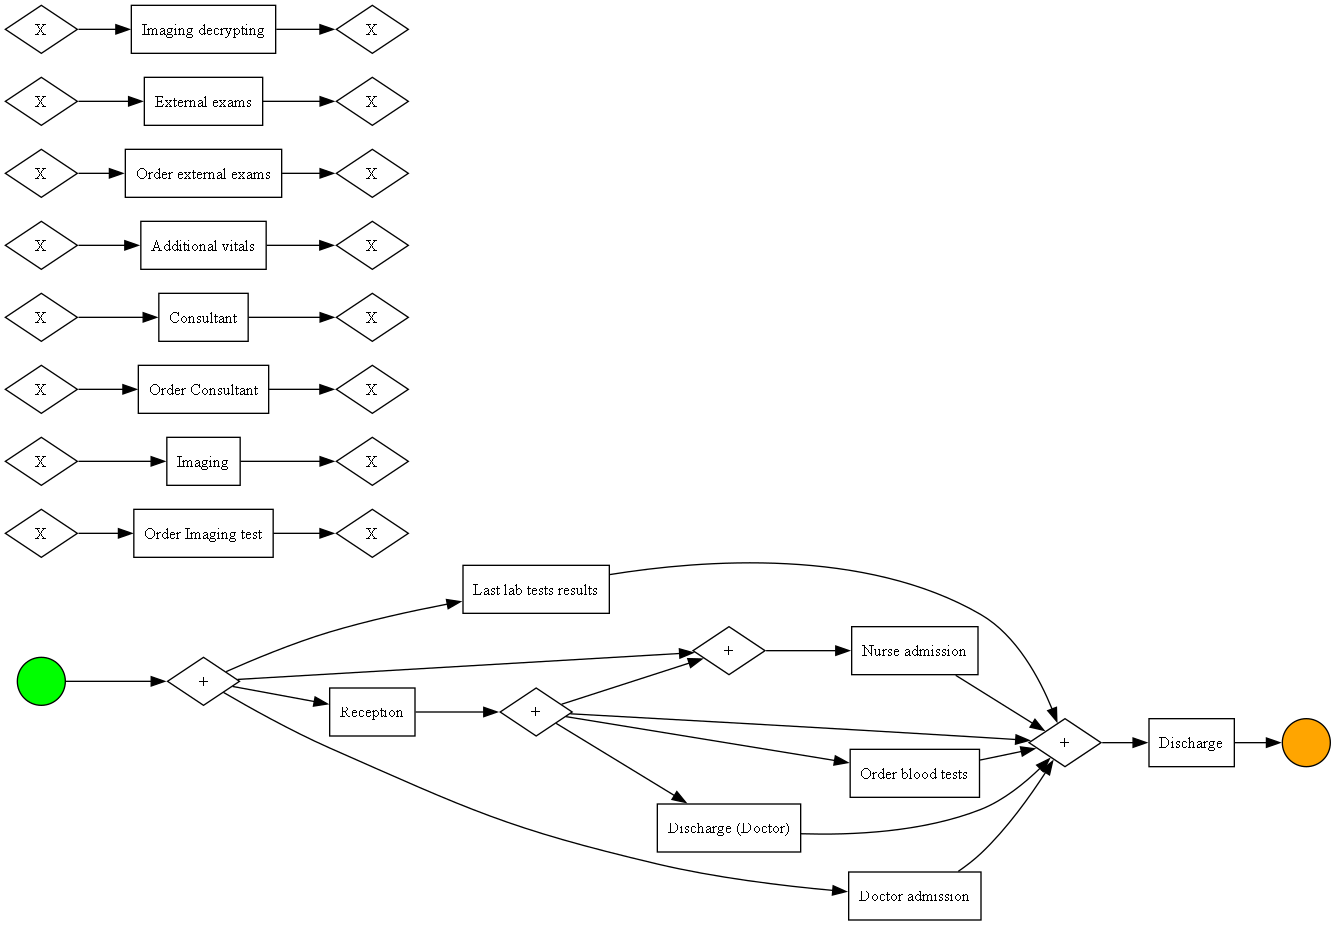

✓ Alpha+ BPMN visualization opened


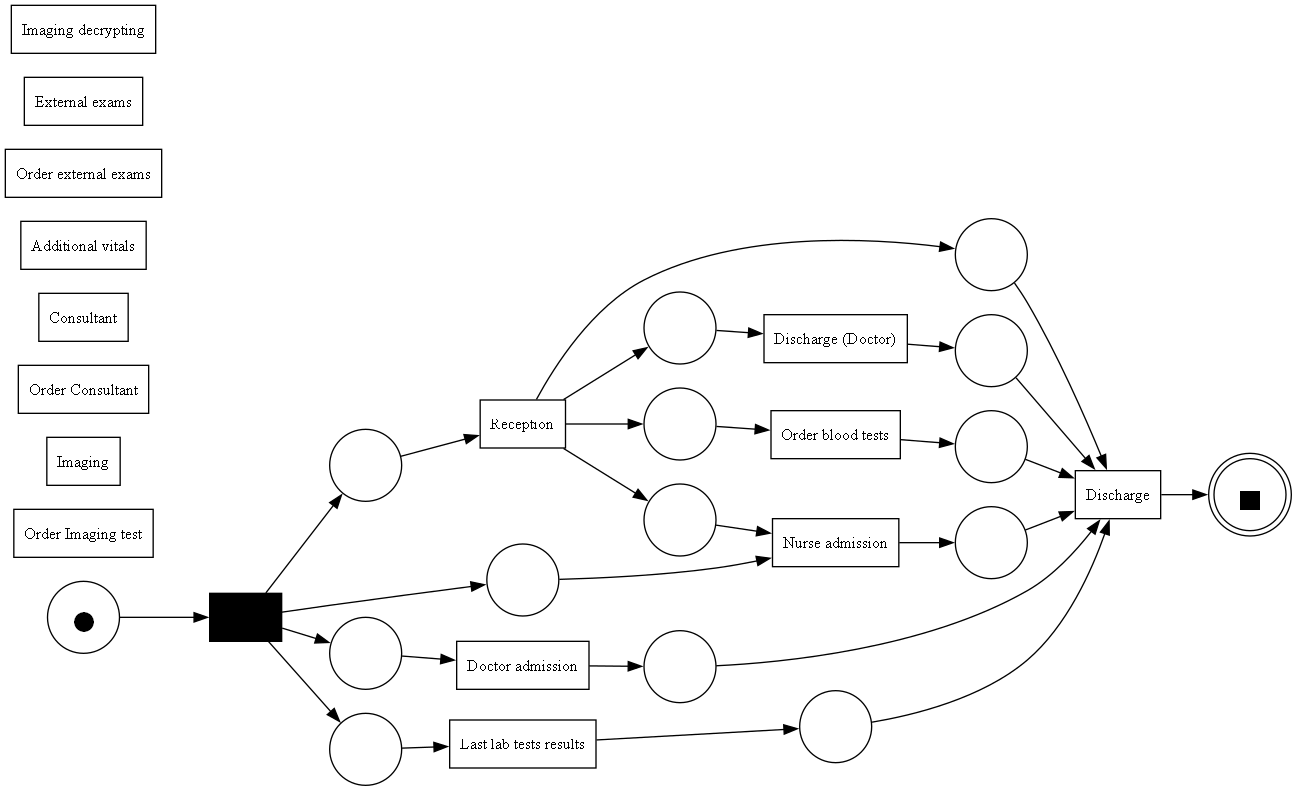

✓ Alpha+ Petri net visualization opened


In [22]:
print("\n--- ALPHA MINER+ AS BPMN ---")

try:
    # Use Alpha+ Miner specifically
    net_alpha_plus, initial_marking_alpha, final_marking_alpha = pm4py.discover_petri_net_alpha_plus(log)
    print("✓ Alpha+ Miner discovered successfully")
    
    # Convert Alpha+ Petri net to BPMN
    bpmn_alpha_plus = pm4py.convert_to_bpmn(net_alpha_plus, initial_marking_alpha, final_marking_alpha)
    print("✓ Alpha+ Miner converted to BPMN")
    
    # Visualize the BPMN model
    pm4py.view_bpmn(bpmn_alpha_plus)
    print("✓ Alpha+ BPMN visualization opened")
    
    # Also show the original Petri net for comparison
    pm4py.view_petri_net(net_alpha_plus, initial_marking_alpha, final_marking_alpha)
    print("✓ Alpha+ Petri net visualization opened")
    
except Exception as e:
    print(f"✗ Alpha+ Miner failed: {e}")
    # Fallback to basic Alpha miner
    try:
        from pm4py.algo.discovery.alpha import algorithm as alpha_miner
        net_alpha, initial_marking_alpha, final_marking_alpha = alpha_miner.apply(log)
        print("✓ Basic Alpha Miner completed successfully (fallback)")
        
        # Convert to BPMN
        bpmn_alpha = pm4py.convert_to_bpmn(net_alpha, initial_marking_alpha, final_marking_alpha)
        pm4py.view_bpmn(bpmn_alpha)
        print("✓ Basic Alpha BPMN visualization opened")
        
    except Exception as e2:
        print(f"✗ All Alpha variations failed: {e2}")

# The Questions have all been completed. We will note the results in the pdf report. 